In [1]:
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core import parse_gauss_code, VirtualLink, VirtualLinkDiagram
from vkt.core.arc_routing_strandref import route_arc_from_strandref


In [2]:
gauss_code = "O1-O2-U1-U2-"
crossings = parse_gauss_code(gauss_code)
link = VirtualLink(crossings)

In [3]:
link.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [4]:
link_diagram=link.to_diagram()

In [5]:
link_diagram.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [ ]:
#link_diagram.admit_virtual_crossing(link_diagram.crossings[0].ref(0),link_diagram.crossings[0].ref(1),1,0)

Crossing(id=2, kind=virtual, sign=None)

In [6]:
link_diagram.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [7]:
 link_diagram.components()

[[StrandRef(crossing=0, strand=0),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=0, strand=1),
  StrandRef(crossing=1, strand=1)]]

In [8]:
route_arc_from_strandref(link_diagram.crossings[0].ref(0))

([0, 4, 4], [1, 1, 3])

In [9]:
route_arc_from_strandref(link_diagram.crossings[0].ref(1))

([1, 3, 3], [0, 0, 4])

In [10]:
route_arc_from_strandref(link_diagram.crossings[1].ref(0))

([4, -1, -1], [5, 5, 0])

In [11]:
route_arc_from_strandref(link_diagram.crossings[1].ref(1))

([5, 5, -2, -2, 0], [4, 6, 6, -1, -1])

In [21]:
gc = 'O1-U2-O3+U1-O4-U5-O6-U3+O2-U4-O5-U6-'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram= VirtualLinkDiagram(link)

TypeError: 'VirtualLink' object is not iterable

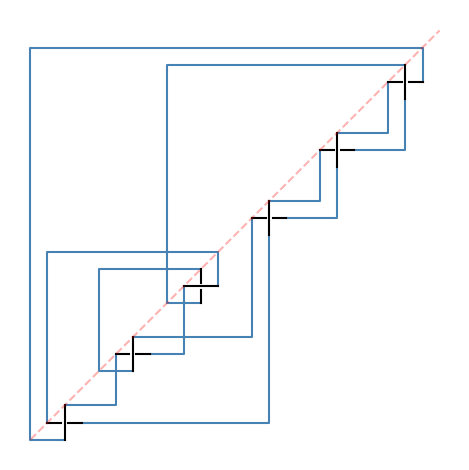

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

all_vals = []

# Plot arcs
for crossing in link.crossings:
    for i in range(2):
        result = route_arc_from_strandref(crossing.ref(i))
        if result is None:
            continue
        xs, ys = result
        all_vals.extend(xs)
        all_vals.extend(ys)
        ax.plot(xs, ys, color='steelblue')

# Plot crossings
for n, crossing in enumerate(link.crossings):
    cx, cy = 4 * n, 4 * n
    if crossing.sign == 1:  # positive: x-axis over, y-axis broken
        ax.plot([cx - 1, cx + 1], [cy, cy], color='black')
        ax.plot([cx, cx], [cy - 1, cy - 0.2], color='black')
        ax.plot([cx, cx], [cy + 0.2, cy + 1], color='black')
    else:  # negative: y-axis over, x-axis broken
        ax.plot([cx, cx], [cy - 1, cy + 1], color='black')
        ax.plot([cx - 1, cx - 0.2], [cy, cy], color='black')
        ax.plot([cx + 0.2, cx + 1], [cy, cy], color='black')

lim = [min(all_vals), max(all_vals)]
ax.plot(lim, [v + 1 for v in lim], color='red', linestyle='--', alpha = .3)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()